In [1]:
import os
import glob
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image, ImageDraw

In [2]:
IMAGES_DIR = "../data/raw/kitti/images"  
LABELS_DIR = "../data/raw/kitti/labels"
OUTPUT_DEMO_DIR = "../results/demo_frames"
os.makedirs(OUTPUT_DEMO_DIR, exist_ok=True)

In [3]:
stats = []
label_files = glob.glob(os.path.join(LABELS_DIR, "*.txt"))

for label_path in label_files:
    with open(label_path, "r") as f:
        for line in f:
            parts = line.strip().split(" ")
            class_name = parts[0]
            if class_name in ["Car", "Pedestrian", "Cyclist"]:
                xmin, ymin, xmax, ymax = float(parts[4]), float(parts[5]), float(parts[6]), float(parts[7])
                width = xmax - xmin
                height = ymax - ymin
                stats.append({"class": class_name, "width": width, "height": height})

df = pd.DataFrame(stats)

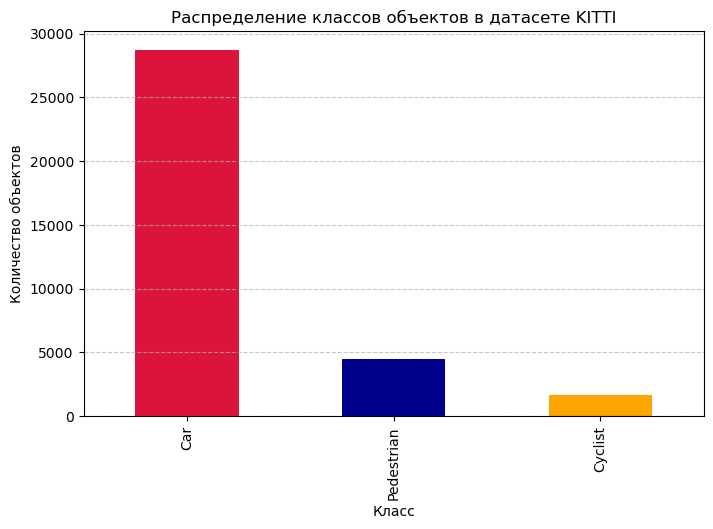

In [4]:
plt.figure(figsize=(8, 5))
df["class"].value_counts().plot(kind="bar", color=["crimson", "darkblue", "orange"])
plt.title("Распределение классов объектов в датасете KITTI")
plt.xlabel("Класс")
plt.ylabel("Количество объектов")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.savefig("../results/tables/class_distribution.png", bbox_inches="tight")
plt.show()

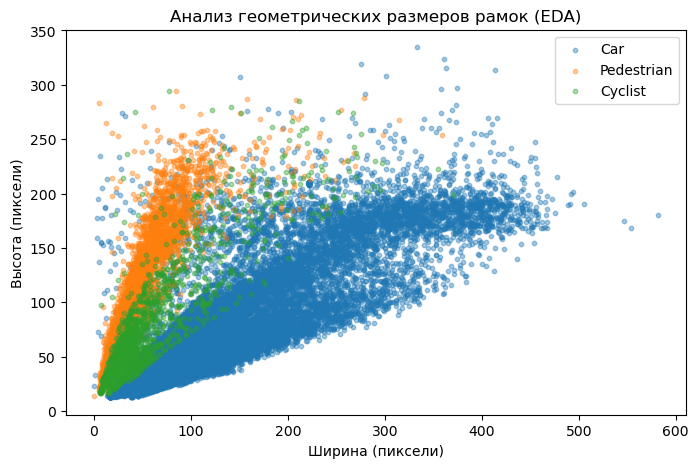

In [5]:
plt.figure(figsize=(8, 5))
for cls in df["class"].unique():
    sub = df[df["class"] == cls]
    plt.scatter(sub["width"], sub["height"], alpha=0.4, label=cls, s=10)
plt.title("Анализ геометрических размеров рамок (EDA)")
plt.xlabel("Ширина (пиксели)")
plt.ylabel("Высота (пиксели)")
plt.legend()
plt.savefig("../results/tables/box_sizes_distribution.png", bbox_inches="tight")
plt.show()

In [6]:
print(f"Всего объектов найдено: {len(df)}")
print(df.groupby("class").describe())

Всего объектов найдено: 34856
              width                                                       \
              count        mean        std   min    25%    50%       75%   
class                                                                      
Car         28742.0  111.949545  90.076827  0.46  45.97  79.70  147.9475   
Cyclist      1627.0   55.849422  52.106782  6.21  22.74  37.94   66.0550   
Pedestrian   4487.0   43.816191  34.049373  0.11  20.14  33.33   59.5850   

                     height                                                \
               max    count        mean        std    min      25%    50%   
class                                                                       
Car         581.42  28742.0   66.121695  50.069089  12.67  30.6425  46.99   
Cyclist     369.83   1627.0   76.885575  53.016805  16.16  39.0600  60.05   
Pedestrian  358.42   4487.0  103.719405  57.420406  13.52  57.0050  87.89   

                              
                 75

In [7]:
for label_path in label_files[:2]:
    base_name = os.path.basename(label_path).replace(".txt", ".png")
    img_path = os.path.join(IMAGES_DIR, base_name)
    
    if not os.path.exists(img_path):
        continue
        
    img = Image.open(img_path).convert("RGB")
    draw = ImageDraw.Draw(img)
    
    with open(label_path, "r") as f:
        for line in f:
            parts = line.strip().split(" ")
            class_name = parts[0]
            if class_name in ["Car", "Pedestrian", "Cyclist"]:
                xmin, ymin, xmax, ymax = float(parts[4]), float(parts[5]), float(parts[6]), float(parts[7])
                draw.rectangle([xmin, ymin, xmax, ymax], outline="lime", width=3)
                draw.text((xmin, ymin - 10), class_name, fill="lime")
                
    save_path = os.path.join(OUTPUT_DEMO_DIR, f"gt_{base_name}")
    img.save(save_path)
    print(f"[ОК] Пример разметки сохранен в: {save_path}")

[ОК] Пример разметки сохранен в: ../results/demo_frames/gt_006145.png
[ОК] Пример разметки сохранен в: ../results/demo_frames/gt_000534.png
